In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import uproot3 as uproot
from math import sqrt, log
import sys,os

from dataframe import dataframe
from config import *
from zx import zx

/cvmfs/sft.cern.ch/lcg/views/LCG_102b_swan/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/uproot3/__init__.py:127: FutureWarning: Consider switching from 'uproot3' to 'uproot', since the new interface became the default in 2020.

    pip install -U uproot

In Python:

    >>> import uproot
    >>> with uproot.open(...) as file:
    ...

  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_102b_swan/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/awkward0/__init__.py:12: FutureWarning: Consider switching from 'awkward0' to 'awkward', since the new interface became the default in 2020.

    pip install -U awkward

In Python:

    >>> import awkward as ak
    >>> new_style_array = ak.from_awkward0(old_style_array)
    >>> old_style_array = ak.to_awkward0(new_style_array)

  warnings.warn(


Welcome to JupyROOT 6.26/08


In [2]:
# ASIMOV
def ams(s, b, sigma_b=None) :
    return sqrt(amssq(s,b,sigma_b))

def amssq(s, b, sigma_b=None) :
    s = float(s)
    b = float(b)
    if sigma_b: 
        sigma_b = float(sigma_b)        
    
    if s == 0:
        return float(0)
    
    if sigma_b is None or sigma_b == 0:
        return 2 * ( (s+b) * log(1+s/b) - s )
    else:
        sb2 = sigma_b*sigma_b
        b2 = b*b
        splub = s+b
        logarg1 = splub*(b+sb2) / ( b2 + splub*sb2 )
        logarg2 = 1 + sb2*s / ( b*(b+sb2) )
        log1 = log(logarg1)
        log2 = log(logarg2)
        return 2 * ( splub * log1 - (b2/sb2) * log2 )

In [3]:
# Plot and calculate significance
def significance(binning, m_inf, m_sup, f_state, var, lumi_plot, NNLOPS, label, year_label, dfVBF, dfGGH, dfOTH, dfQQZZ, dfGGZZ, dfZX, sign):
    if(f_state == 'inclusive'):
        selzx = (dfZX.ZZMass >= m_inf) & (dfZX.ZZMass <= m_sup)
        selqqzz = (dfQQZZ.ZZMass >= m_inf) & (dfQQZZ.ZZMass <= m_sup) 
        selggzz = (dfGGZZ.ZZMass >= m_inf) & (dfGGZZ.ZZMass <= m_sup) 
        selvbf = (dfVBF.ZZMass >= m_inf) & (dfVBF.ZZMass <= m_sup) 
        selggh = (dfGGH.ZZMass >= m_inf) & (dfGGH.ZZMass <= m_sup) 
        seloth = (dfOTH.ZZMass >= m_inf) & (dfOTH.ZZMass <= m_sup)
#         shift = 5
    if(f_state != 'inclusive'):
        if(f_state == '4e'): 
            sel_f_state_zx = dfZX.FinState == 0
#             shift = 1
        elif(f_state == '4mu'): 
            sel_f_state_zx = dfZX.FinState == 1
#             shift = 2
        elif(f_state == '2e2mu'): 
            sel_f_state_zx = (dfZX.FinState == 2) | (dfZX.FinState == 3)
#             shift = 3
        selzx = (dfZX.ZZMass >= m_inf) & (dfZX.ZZMass <= m_sup) & sel_f_state_zx
        selqqzz = (dfQQZZ.ZZMass >= m_inf) & (dfQQZZ.ZZMass <= m_sup) & (dfQQZZ.FinState == f_state)
        selggzz = (dfGGZZ.ZZMass >= m_inf) & (dfGGZZ.ZZMass <= m_sup) & (dfGGZZ.FinState == f_state)
        selvbf = (dfVBF.ZZMass >= m_inf) & (dfVBF.ZZMass <= m_sup) & (dfVBF.FinState == f_state)
        selggh = (dfGGH.ZZMass >= m_inf) & (dfGGH.ZZMass <= m_sup) & (dfGGH.FinState == f_state)
        seloth = (dfOTH.ZZMass >= m_inf) & (dfOTH.ZZMass <= m_sup) & (dfOTH.FinState == f_state)
    
    #NNLOPS weights or not
    if(NNLOPS == False): w_var = 'weight'
    elif(NNLOPS == True): w_var = 'weight_NNLOPS'


    n, bins, _= plt.hist([dfZX[selzx][var], dfGGZZ[selggzz][var], dfQQZZ[selqqzz][var], dfGGH[selggh][var], dfVBF[selvbf][var], dfOTH[seloth][var]], 
                         bins = binning, 
                         weights = [dfZX[selzx]['yield_SR'], dfGGZZ[selggzz][w_var], dfQQZZ[selqqzz][w_var], dfGGH[selggh][w_var], dfVBF[selvbf][w_var], dfOTH[seloth][w_var]], 
                         color = colors, 
                         histtype='bar', 
                         label = labels, 
                         stacked = True)
    # Signal and background events to calculate Asimov (Suddivision in different final states)
    bkg = n[2]
    sig = n[5] - n[2]
    print(sig)
    i = 0
    asi = []
    while i<len(binning)-1:
        asi.append(ams(sig[i], bkg[i], 0.13*bkg[i]))
        sign[year_label,f_state,i] = asi[i]
        i += 1 
    
    if var == 'ZZPt': 
        xlim_sup = 300.
        plt.xlim(0,xlim_sup)
        binning[len(binning)-1] = xlim_sup
#     midPoints = [(binning[i]+binning[i+1])/2 for i in range(len(binning)-1)]
    plt.rcParams['figure.figsize']= [8,4.8]
#     for i in range(len(midPoints)):
#         plt.text(midPoints[i],n[5][i]+shift,'{:.1f}'.format(asi[i]),ha='center',va='center',fontsize='large')
    plt.xlabel(label, fontsize=13)
    if f_state == 'inclusive': 
        plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
    else: 
        plt.title('$\\bf{%s}$' %f_state, loc = 'left')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',borderaxespad=0.,ncol=2, fontsize='large')
    if year_label=='run2': 
        plt.title(str("{:.0f}".format(lumi_plot))+' fb$^{-1}$ (13 TeV)', loc = 'right')
        plt.savefig('plots/%s_run2_%s.png' %(var,f_state), dpi=400, bbox_inches='tight') 
        plt.savefig('plots/%s_run2_%s.pdf' %(var,f_state), dpi=400, bbox_inches='tight')
    else: 
        plt.title(str("{:.1f}".format(lumi_plot))+' fb$^{-1}$ (13 TeV)', loc = 'right')
        plt.savefig('plots/%s_%s_%s.png' %(var,year_label,f_state), dpi=400, bbox_inches='tight')
        plt.savefig('plots/%s_%s_%s.pdf' %(var,year_label,f_state), dpi=400, bbox_inches='tight')
    plt.show()
    
    for index,value in enumerate(asi):
        print('Bin'+(str(index+1)),value)
    
def significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel):
    sign = {}
#     for year in ['run2']:
    for year in ['2016']:       
        if year == 'run2':
            lumiPlot = 137
            vbf = [d_sig[year]['VBF'] for year in [2016,2017,2018]] 
            ggh = [d_sig[year]['ggH'] for year in [2016,2017,2018]]
            other = [d_sig[year]['other'] for year in [2016,2017,2018]]
            qqzz = [d_bkg[year]['qqzz'] for year in [2016,2017,2018]]
            ggzz = [d_bkg[year]['ggzz'] for year in [2016,2017,2018]]
            zx = [d_ZX[year] for year in [2016,2017,2018]]
            dfVBF = pd.concat(vbf)
            dfGGH = pd.concat(ggh)
            dfOTH = pd.concat(other)
            dfQQZZ = pd.concat(qqzz)
            dfGGZZ = pd.concat(ggzz)
            dfZX = pd.concat(zx)
        else: 
            lumiPlot = 35.9
            dfVBF = d_sig[int(year)]['VBF']
            dfGGH = d_sig[int(year)]['ggH']
            dfOTH = d_sig[int(year)]['other']
            dfQQZZ = d_bkg[int(year)]['qqzz']
            dfGGZZ = d_bkg[int(year)]['ggzz']
            dfZX = d_ZX[int(year)]
            if year == '2016': lumiPlot = 35.9
            if year == '2017': lumiPlot = 41.5
            if year == '2018': lumiPlot = 59.7

        for finState in ['inclusive', '2e2mu', '4e', '4mu']:
#         for finState in ['inclusive']:
            if year == 'run2' and finState != 'inclusive': continue
#             if year != 'run2' and finState == 'inclusive': continue
            significance(binBoundaries, massInf, massSup, finState, variable, lumiPlot, NNLOPS, plotLabel, year, dfVBF, dfGGH, dfOTH, dfQQZZ, dfGGZZ, dfZX, sign)
    print(sign)

In [4]:
def optimization_lower(m_inf, m_sup, var, Z, step, edge, initial_boundary):
    selzx = (dfZX.ZZMass >= m_inf) & (dfZX.ZZMass <= m_sup)
    selqqzz = (dfQQZZ.ZZMass >= m_inf) & (dfQQZZ.ZZMass <= m_sup) 
    selggzz = (dfGGZZ.ZZMass >= m_inf) & (dfGGZZ.ZZMass <= m_sup) 
    selvbf = (dfVBF.ZZMass >= m_inf) & (dfVBF.ZZMass <= m_sup) 
    selggh = (dfGGH.ZZMass >= m_inf) & (dfGGH.ZZMass <= m_sup) 
    seloth = (dfOTH.ZZMass >= m_inf) & (dfOTH.ZZMass <= m_sup)
    
    #NNLOPS weights or not
    if(NNLOPS == False): w_var = 'weight'
    elif(NNLOPS == True): w_var = 'weight_NNLOPS'


    sig = bkg = asi = 0
#     Z = 2.5 # Cut-off in Asimov significance
#     step = 5
#     edge = 350
    binning = [edge, initial_boundary]

    while binning[0] > 0:
        asi = 0
        while asi < Z:
            n, bins, _= plt.hist([dfZX[selzx][var], dfGGZZ[selggzz][var], dfQQZZ[selqqzz][var], dfGGH[selggh][var], dfVBF[selvbf][var], dfOTH[seloth][var]], 
                     bins = binning, 
                     weights = [dfZX[selzx]['yield_SR'], dfGGZZ[selggzz][w_var], dfQQZZ[selqqzz][w_var], dfGGH[selggh][w_var], dfVBF[selvbf][w_var], dfOTH[seloth][w_var]], 
                     color = colors, 
                     histtype='bar', 
                     label = labels, 
                     stacked = True)
            bkg = n[2]
            sig = n[5] - n[2]
            asi = ams(sig[0], bkg[0], 0.13*bkg[0])
            binning[0] -= step
            if binning[0] <= 0: break
        if binning[0] > 0:
            binning.insert(0, binning[0] - step)
    
    print(len(binning)-1)
    print(binning)
    
    
def optimization_upper(m_inf, m_sup, var, Z, step, edge, initial_boundary):
    selzx = (dfZX.ZZMass >= m_inf) & (dfZX.ZZMass <= m_sup)
    selqqzz = (dfQQZZ.ZZMass >= m_inf) & (dfQQZZ.ZZMass <= m_sup) 
    selggzz = (dfGGZZ.ZZMass >= m_inf) & (dfGGZZ.ZZMass <= m_sup) 
    selvbf = (dfVBF.ZZMass >= m_inf) & (dfVBF.ZZMass <= m_sup) 
    selggh = (dfGGH.ZZMass >= m_inf) & (dfGGH.ZZMass <= m_sup) 
    seloth = (dfOTH.ZZMass >= m_inf) & (dfOTH.ZZMass <= m_sup)
    
    #NNLOPS weights or not
    if(NNLOPS == False): w_var = 'weight'
    elif(NNLOPS == True): w_var = 'weight_NNLOPS'


    sig = bkg = asi = 0
#     Z = 3 # Cut-off in Asimov significance
#     step = 5
#     edge = 5
    binning = [0, edge]

    while binning[len(binning)-1] < 1:
        asi = 0
        while asi < Z:
            n, bins, _= plt.hist([dfZX[selzx][var], dfGGZZ[selggzz][var], dfQQZZ[selqqzz][var], dfGGH[selggh][var], dfVBF[selvbf][var], dfOTH[seloth][var]], 
                     bins = binning, 
                     weights = [dfZX[selzx]['yield_SR'], dfGGZZ[selggzz][w_var], dfQQZZ[selqqzz][w_var], dfGGH[selggh][w_var], dfVBF[selvbf][w_var], dfOTH[seloth][w_var]], 
                     color = colors, 
                     histtype='bar', 
                     label = labels, 
                     stacked = True)
            bkg = n[2]
            sig = n[5] - n[2]
            asi = ams(sig[0], bkg[0], 0.13*bkg[0])
            binning[len(binning)-1] += step
#             if binning[len(binning)-1] <= 0: break
#         if binning[len(binning)-1] > 0:
        binning.insert(len(binning)-1, binning[len(binning)-1] - step)

    print(len(binning)-1)
    print(binning)

# Create dataframe

In [5]:
d_sig = {}
d_bkg = {}
d_sig,d_bkg = dataframe()

Signal df created, 2016
Background df created, 2016
2016 skimmed df created


In [6]:
d_ZX = {}
d_ZX = zx(d_bkg)

2016 done


# ZZPt

[ 7.16928081 11.71612575  9.46497581  9.81583654  6.36049565  5.47655241
  5.84194272  4.3063362   1.96114446]


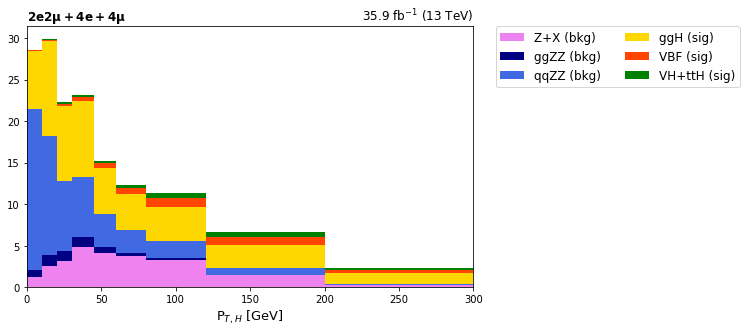

Bin1 1.2446374897779078
Bin2 2.1471586829072895
Bin3 2.1271513576026417
Bin4 2.1519654384833684
Bin5 1.7785489736833486
Bin6 1.7565318464893769
Bin7 2.047937262053499
Bin8 2.2209158254530035
Bin9 2.0715898764894267
[3.2127016  5.22215222 4.27348623 4.44867892 2.89423768 2.51527139
 2.63396596 1.90806046 0.64819495]


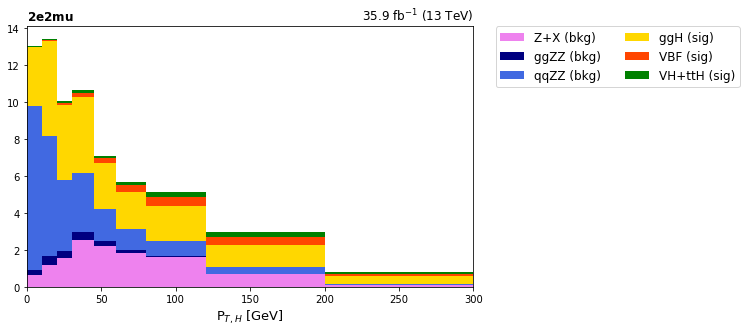

Bin1 0.8980609668049994
Bin2 1.5457009136831117
Bin3 1.5190139892178376
Bin4 1.5261280885150528
Bin5 1.2290323641413916
Bin6 1.2289591913393292
Bin7 1.4099621656743015
Bin8 1.4868477968517442
Bin9 1.081882727275058
[1.24791042 2.08774224 1.66351736 1.7183639  1.11569632 0.98164626
 1.05940239 0.81059488 0.2689239 ]


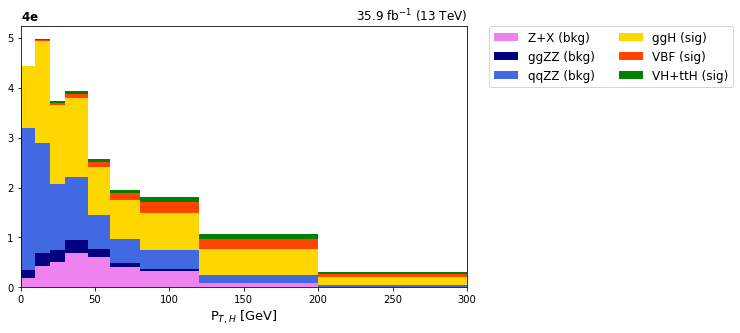

Bin1 0.6397781850741949
Bin2 1.0809633376507013
Bin3 1.0178335068521032
Bin4 1.0165573639984429
Bin5 0.8233684331367127
Bin6 0.8651801094584644
Bin7 1.0222741299811695
Bin8 1.1852975470903877
Bin9 0.8603936767700461
[2.7086688  4.4062313  3.52797223 3.64879373 2.35056165 1.97963477
 2.14857437 1.58768086 0.48328042]


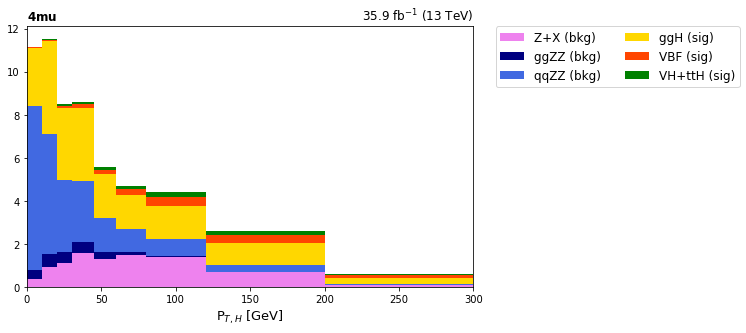

Bin1 0.8261351154324016
Bin2 1.4164026778203902
Bin3 1.3681852218007546
Bin4 1.4129226881375418
Bin5 1.1483827200147176
Bin6 1.0585641260070209
Bin7 1.2343849199543686
Bin8 1.2915716085439943
Bin9 0.9370030154993509
{('2016', 'inclusive', 0): 1.2446374897779078, ('2016', 'inclusive', 1): 2.1471586829072895, ('2016', 'inclusive', 2): 2.1271513576026417, ('2016', 'inclusive', 3): 2.1519654384833684, ('2016', 'inclusive', 4): 1.7785489736833486, ('2016', 'inclusive', 5): 1.7565318464893769, ('2016', 'inclusive', 6): 2.047937262053499, ('2016', 'inclusive', 7): 2.2209158254530035, ('2016', 'inclusive', 8): 2.0715898764894267, ('2016', '2e2mu', 0): 0.8980609668049994, ('2016', '2e2mu', 1): 1.5457009136831117, ('2016', '2e2mu', 2): 1.5190139892178376, ('2016', '2e2mu', 3): 1.5261280885150528, ('2016', '2e2mu', 4): 1.2290323641413916, ('2016', '2e2mu', 5): 1.2289591913393292, ('2016', '2e2mu', 6): 1.4099621656743015, ('2016', '2e2mu', 7): 1.4868477968517442, ('2016', '2e2mu', 8): 1.0818827272

In [8]:
binBoundaries = [0.,10.,20.,30.,45.,60.,80.,120.,200.,1000.]
massInf=105
massSup=140
NNLOPS=False
variable = 'ZZPt'
plotLabel = 'P$_{T,H}$ [GeV]'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

In [ ]:
massInf=105
massSup=140
# finState='2e2mu'
NNLOPS=False
# years_plot=[2016,2017,2018]

variable = 'ZZPt'
plotLabel = 'P$_{T,H}$ [GeV]'
vbf = [d_sig[year]['VBF'] for year in [2016,2017,2018]] 
ggh = [d_sig[year]['ggH'] for year in [2016,2017,2018]]
other = [d_sig[year]['other'] for year in [2016,2017,2018]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016,2017,2018]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016,2017,2018]]
zx = [d_ZX[year] for year in [2016,2017,2018]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=5 
edge=195
initial_boundary=200
Z_cut = 3.1 #Cut-off in Asimov significance
optimization_lower(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0, 10, 20, 30, 45, 70, 105, 145, 200, 1300]
massInf=105
massSup=140
NNLOPS=False
variable = 'ZZPt'
plotLabel = 'P$_{T,H}$ [GeV]'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# ZZy

In [ ]:
# binBoundaries = [0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.2, 1.6, 2.5] #Atlas binning
# binBoundaries = [0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.05, 1.20, 1.35, 1.50, 1.65, 1.80, 1.95, 2.10, 2.25, 2.5] #Uniform binning
binBoundaries = [0.0,0.15,0.3,0.6,0.9,1.2,2.5] #Our original binning
massInf=105
massSup=140
NNLOPS=False
variable = 'ZZy'
plotLabel = '|y$_{H}$|'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

In [ ]:
massInf=105
massSup=140
NNLOPS=False

variable = 'ZZy'
plotLabel = '|y$_{H}$|'
vbf = [d_sig[year]['VBF'] for year in [2016,2017,2018]] 
ggh = [d_sig[year]['ggH'] for year in [2016,2017,2018]]
other = [d_sig[year]['other'] for year in [2016,2017,2018]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016,2017,2018]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016,2017,2018]]
zx = [d_ZX[year] for year in [2016,2017,2018]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=2.4
initial_boundary=2.5
Z_cut = 2.55 #Cut-off in Asimov significance
optimization_lower(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
# binBoundaries = [0, 0.2, 0.35, 0.5, 0.65, 0.8, 1, 1.2, 1.45, 2.5] #Z_cut = 2.5
# binBoundaries = [0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.95, 1.15, 1.4, 2.5] #Z_cut = 2.55
binBoundaries = [0, 0.1, 0.25, 0.4, 0.55, 0.75, 0.95, 1.15, 1.40, 2.5] #Z_cut = 2.6
massInf=105
massSup=140
NNLOPS=False
variable = 'ZZy'
plotLabel = '|y$_{H}$|'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# D0m

[ 9.19283866 17.54695811 17.39811013 11.75459542  6.22054632]


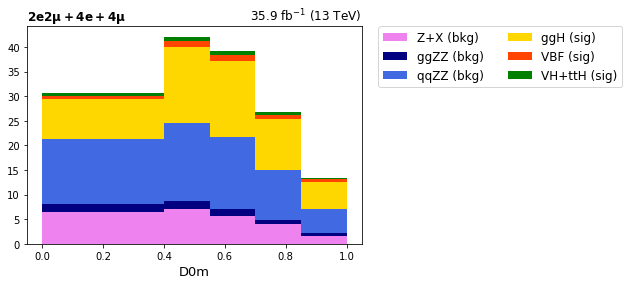

Bin1 1.5712941317107862
Bin2 2.619632793572915
Bin3 2.776891217009866
Bin4 2.38605479208637
Bin5 1.9319106637948606
[5.69109077 7.5476816  6.86084199 4.91785786 2.99999291]


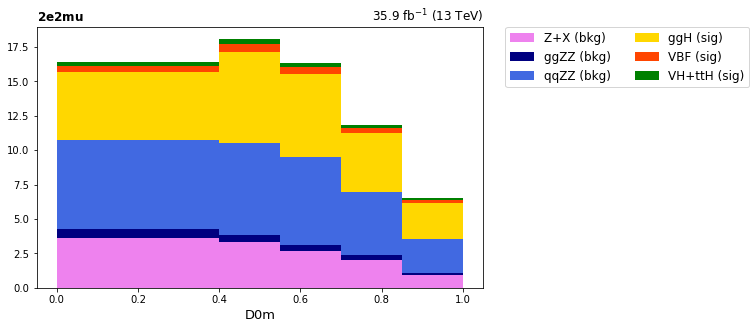

Bin1 1.4652299588030782
Bin2 1.9137814674202143
Bin3 1.8452224366121006
Bin4 1.5848162625874873
Bin5 1.3739942406065417
[0.97764643 3.28859281 3.44771849 2.28988793 1.05410318]


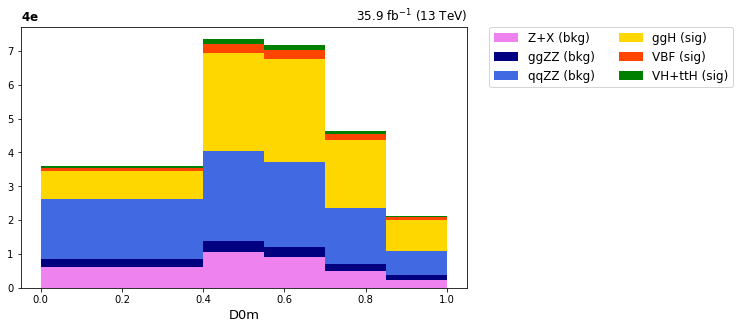

Bin1 0.5568255568030218
Bin2 1.4059728163491352
Bin3 1.5222596343947368
Bin4 1.2843825104121565
Bin5 0.8854101430311605
[2.52410146 6.71068371 7.08954966 4.54684963 2.16645023]


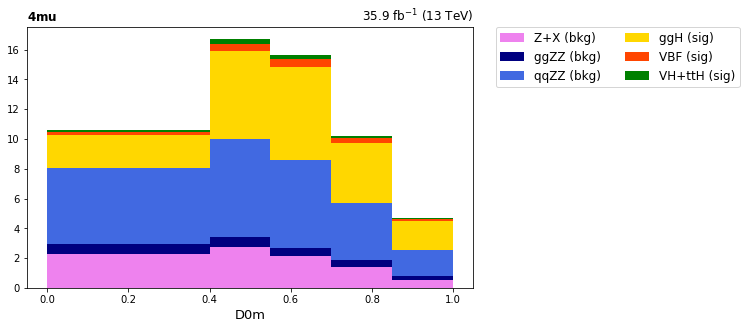

Bin1 0.7901709098948912
Bin2 1.7638794868939773
Bin3 1.9965442814157277
Bin4 1.6189173507583583
Bin5 1.1831931461729117
{('2016', 'inclusive', 0): 1.5712941317107862, ('2016', 'inclusive', 1): 2.619632793572915, ('2016', 'inclusive', 2): 2.776891217009866, ('2016', 'inclusive', 3): 2.38605479208637, ('2016', 'inclusive', 4): 1.9319106637948606, ('2016', '2e2mu', 0): 1.4652299588030782, ('2016', '2e2mu', 1): 1.9137814674202143, ('2016', '2e2mu', 2): 1.8452224366121006, ('2016', '2e2mu', 3): 1.5848162625874873, ('2016', '2e2mu', 4): 1.3739942406065417, ('2016', '4e', 0): 0.5568255568030218, ('2016', '4e', 1): 1.4059728163491352, ('2016', '4e', 2): 1.5222596343947368, ('2016', '4e', 3): 1.2843825104121565, ('2016', '4e', 4): 0.8854101430311605, ('2016', '4mu', 0): 0.7901709098948912, ('2016', '4mu', 1): 1.7638794868939773, ('2016', '4mu', 2): 1.9965442814157277, ('2016', '4mu', 3): 1.6189173507583583, ('2016', '4mu', 4): 1.1831931461729117}


In [7]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

In [ ]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0m'
plotLabel = 'D0m'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
# binBoundaries = [0,0.45,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# Dcp

[ 6.85634542 11.56174695 12.53533506 12.6209903  11.61021128  6.92841964]


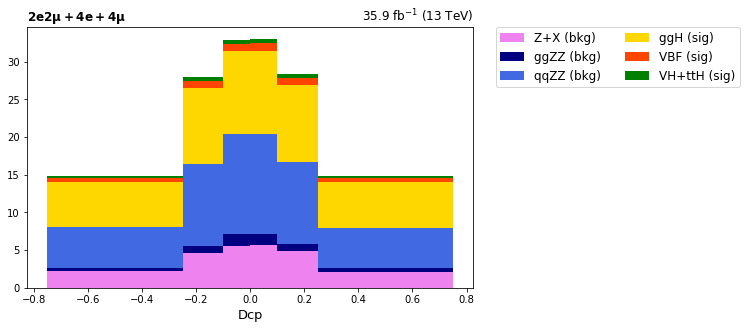

Bin1 1.9997808249470213
Bin2 2.2403732845969353
Bin3 2.14580025269558
Bin4 2.1607330416880406
Bin5 2.2268726777252668
Bin6 2.0293675163529468
[3.8987171  5.42861065 4.67404428 4.71080433 5.43048455 3.87480423]


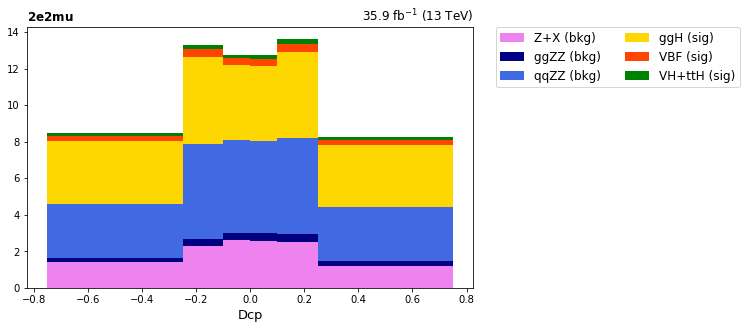

Bin1 1.5529874757507947
Bin2 1.6308723745987561
Bin3 1.4043921596879174
Bin4 1.421957747198867
Bin5 1.603791437080911
Bin6 1.570503196722291
[0.93192008 1.97807891 2.58929933 2.60779055 1.97621851 0.97464145]


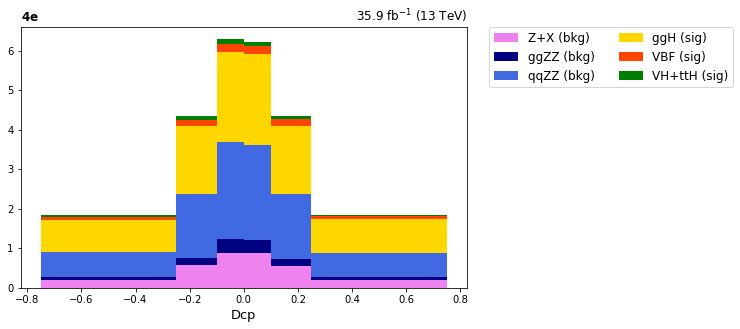

Bin1 0.8519089458474999
Bin2 1.1230800179812679
Bin3 1.1793434130121445
Bin4 1.198479047926732
Bin5 1.1186243789571089
Bin6 0.8955923573380391
[2.02570824 4.15505739 5.27199145 5.30239543 4.20350822 2.07897396]


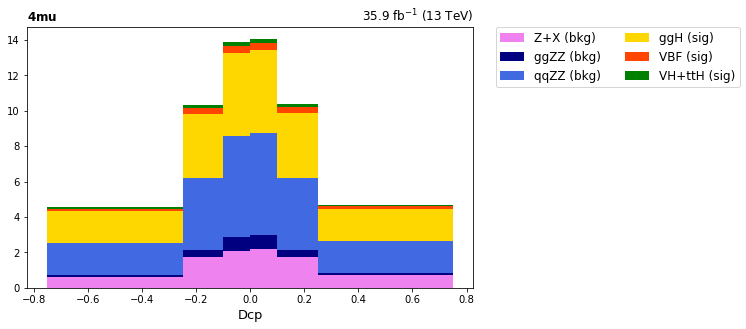

Bin1 1.115343883073887
Bin2 1.43579506516477
Bin3 1.5235486286965207
Bin4 1.5198464572812262
Bin5 1.4503184070299473
Bin6 1.122650555432787
{('2016', 'inclusive', 0): 1.9997808249470213, ('2016', 'inclusive', 1): 2.2403732845969353, ('2016', 'inclusive', 2): 2.14580025269558, ('2016', 'inclusive', 3): 2.1607330416880406, ('2016', 'inclusive', 4): 2.2268726777252668, ('2016', 'inclusive', 5): 2.0293675163529468, ('2016', '2e2mu', 0): 1.5529874757507947, ('2016', '2e2mu', 1): 1.6308723745987561, ('2016', '2e2mu', 2): 1.4043921596879174, ('2016', '2e2mu', 3): 1.421957747198867, ('2016', '2e2mu', 4): 1.603791437080911, ('2016', '2e2mu', 5): 1.570503196722291, ('2016', '4e', 0): 0.8519089458474999, ('2016', '4e', 1): 1.1230800179812679, ('2016', '4e', 2): 1.1793434130121445, ('2016', '4e', 3): 1.198479047926732, ('2016', '4e', 4): 1.1186243789571089, ('2016', '4e', 5): 0.8955923573380391, ('2016', '4mu', 0): 1.115343883073887, ('2016', '4mu', 1): 1.43579506516477, ('2016', '4mu', 2): 1.5235

In [8]:
binBoundaries = [-0.75,-0.25,-0.10,0,0.10,0.25,0.75] 
massInf=105
massSup=140
NNLOPS=False
variable = 'Dcp'
plotLabel = 'Dcp'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

In [ ]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0m'
plotLabel = 'D0m'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# D0hp

[11.95976059 19.68122246 12.39805832  9.12145664  8.95255063]


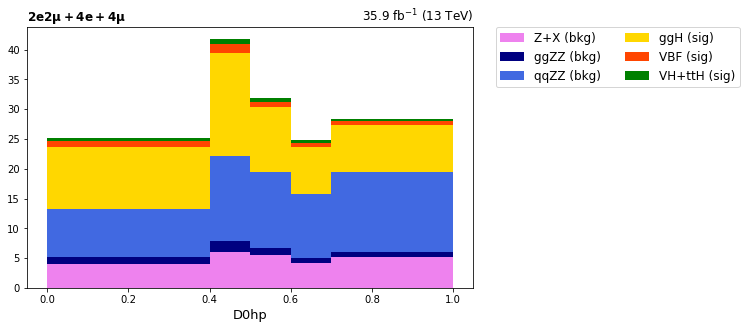

Bin1 2.583362105320964
Bin2 3.0737947259538525
Bin3 2.1809656200864596
Bin4 1.851918477868208
Bin5 1.6171541045323647
[7.56374038 8.23224266 4.78302862 3.25022151 4.18823195]


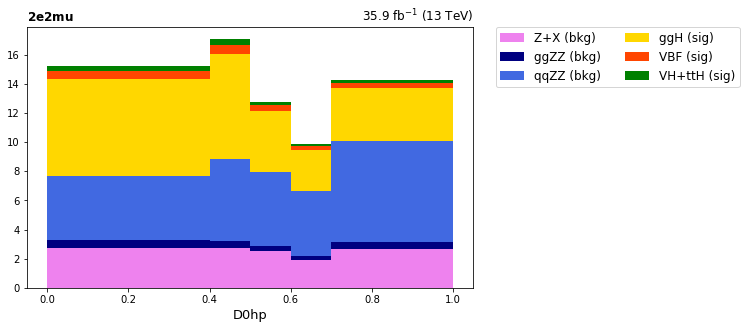

Bin1 2.2259025783789816
Bin2 2.2486399988125605
Bin3 1.444798673270408
Bin4 1.1061927384054633
Bin5 1.1369464182831246
[1.38207829 3.74215732 2.49425927 1.98385092 1.45560303]


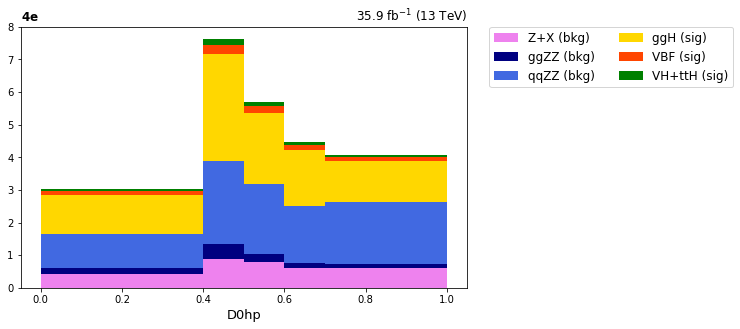

Bin1 0.9462947595907313
Bin2 1.6102666432563613
Bin3 1.2159314693840788
Bin4 1.0995790470280313
Bin5 0.8106086883494399
[3.01394192 7.70682247 5.12077043 3.88738421 3.30871566]


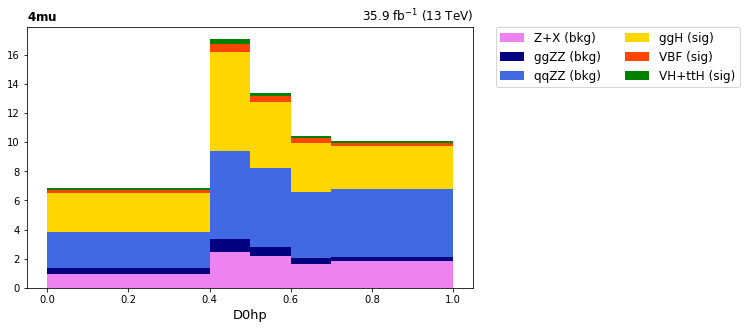

Bin1 1.3280043937748098
Bin2 2.0621673389900246
Bin3 1.5125120068782527
Bin4 1.3130545402194176
Bin5 1.111407560940757
{('2016', 'inclusive', 0): 2.583362105320964, ('2016', 'inclusive', 1): 3.0737947259538525, ('2016', 'inclusive', 2): 2.1809656200864596, ('2016', 'inclusive', 3): 1.851918477868208, ('2016', 'inclusive', 4): 1.6171541045323647, ('2016', '2e2mu', 0): 2.2259025783789816, ('2016', '2e2mu', 1): 2.2486399988125605, ('2016', '2e2mu', 2): 1.444798673270408, ('2016', '2e2mu', 3): 1.1061927384054633, ('2016', '2e2mu', 4): 1.1369464182831246, ('2016', '4e', 0): 0.9462947595907313, ('2016', '4e', 1): 1.6102666432563613, ('2016', '4e', 2): 1.2159314693840788, ('2016', '4e', 3): 1.0995790470280313, ('2016', '4e', 4): 0.8106086883494399, ('2016', '4mu', 0): 1.3280043937748098, ('2016', '4mu', 1): 2.0621673389900246, ('2016', '4mu', 2): 1.5125120068782527, ('2016', '4mu', 3): 1.3130545402194176, ('2016', '4mu', 4): 1.111407560940757}


In [9]:
binBoundaries = [0,0.4,0.5,0.6,0.7,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0hp'
plotLabel = 'D0hp'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

13
[0, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.9500000000000002, 1.0000000000000002]


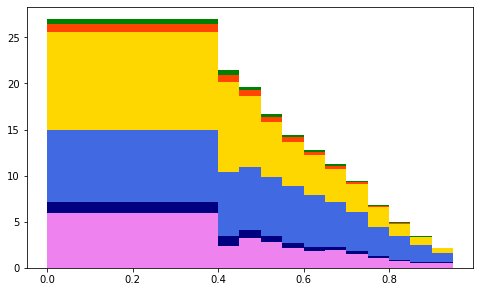

In [25]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0hp'
plotLabel = 'D0hp'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2.3 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# Dint

[11.58967279 11.37350349 10.62896846 28.51664865]


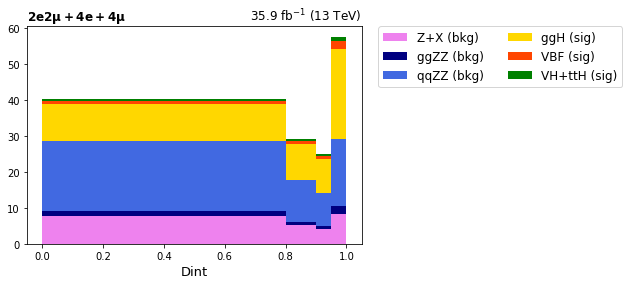

Bin1 1.6423560332865517
Bin2 2.1125297983045392
Bin3 2.235064730882899
Bin4 3.65084322809077
[ 5.93661329  4.48168197  4.12551129 13.46943344]


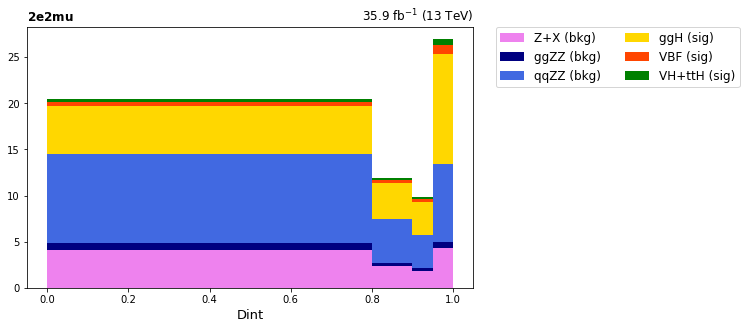

Bin1 1.2988261512201733
Bin2 1.4075803224479968
Bin3 1.478582257387763
Bin4 2.8365649079927513
[1.7741742  2.21720054 2.17386605 4.89267794]


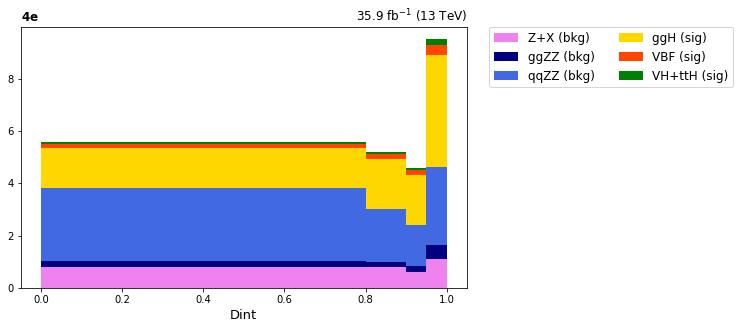

Bin1 0.820109642103308
Bin2 1.1235720558677624
Bin3 1.2113920851673123
Bin4 1.8955462876030844
[ 3.87888531  4.67462098  4.32959112 10.15453727]


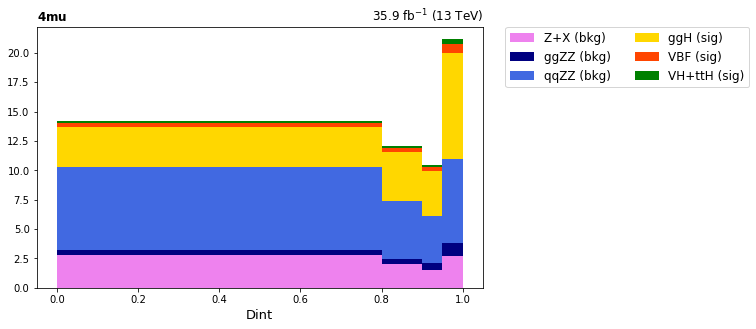

Bin1 1.0453307560781278
Bin2 1.4671094479697537
Bin3 1.4955703375549818
Bin4 2.44041051464439
{('2016', 'inclusive', 0): 1.6423560332865517, ('2016', 'inclusive', 1): 2.1125297983045392, ('2016', 'inclusive', 2): 2.235064730882899, ('2016', 'inclusive', 3): 3.65084322809077, ('2016', '2e2mu', 0): 1.2988261512201733, ('2016', '2e2mu', 1): 1.4075803224479968, ('2016', '2e2mu', 2): 1.478582257387763, ('2016', '2e2mu', 3): 2.8365649079927513, ('2016', '4e', 0): 0.820109642103308, ('2016', '4e', 1): 1.1235720558677624, ('2016', '4e', 2): 1.2113920851673123, ('2016', '4e', 3): 1.8955462876030844, ('2016', '4mu', 0): 1.0453307560781278, ('2016', '4mu', 1): 1.4671094479697537, ('2016', '4mu', 2): 1.4955703375549818, ('2016', '4mu', 3): 2.44041051464439}


In [7]:
binBoundaries = [0,0.8,0.9,0.95,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'Dint'
plotLabel = 'Dint'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

13
[0, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.9500000000000002, 1.0000000000000002]


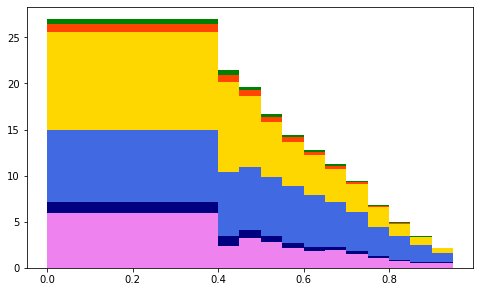

In [25]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0hp'
plotLabel = 'D0hp'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2.3 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# DL1

[10.26768339 22.78504628 14.87578079  7.61080066  6.57373752]


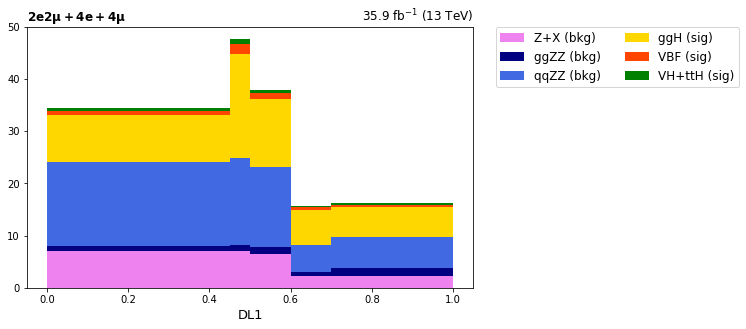

Bin1 1.6254218161923362
Bin2 3.2778482764967882
Bin3 2.3369663102834353
Bin4 2.1758431062544465
Bin5 1.7601882906463777
[ 4.95981768 12.18156302  6.48197488  2.29730957  2.09679999]


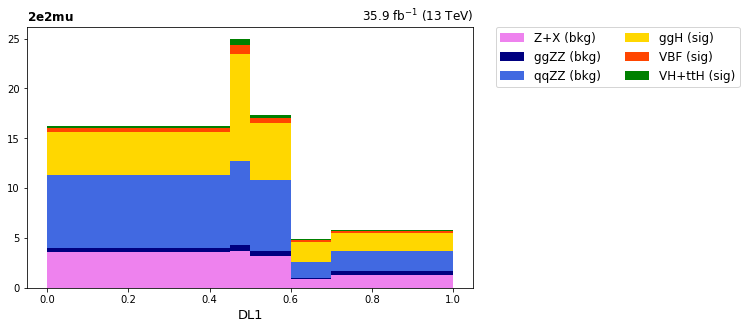

Bin1 1.2529945661398407
Bin2 2.66831834633986
Bin3 1.6433735012753412
Bin4 1.2341108321542844
Bin5 0.9697861421114882
[1.49189989 3.09807416 3.00892281 1.84453121 1.61452076]


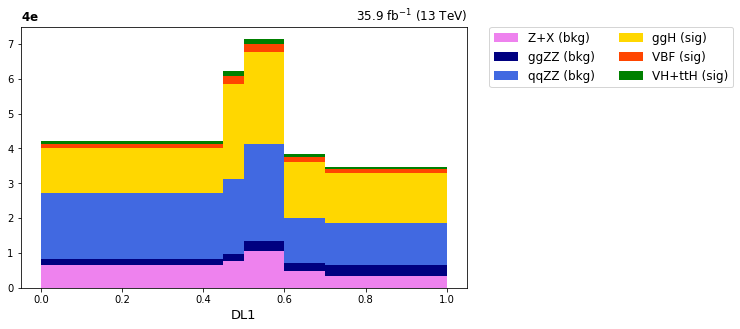

Bin1 0.815965553744014
Bin2 1.4898322361775675
Bin3 1.2875157855981383
Bin4 1.1325097815903946
Bin5 1.0333734750578443
[3.81596582 7.50540911 5.3848831  3.46895988 2.86241678]


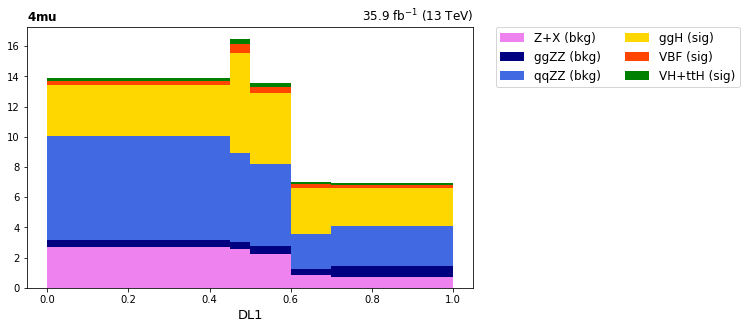

Bin1 1.0417695705842605
Bin2 2.0574454826673674
Bin3 1.5914287477491187
Bin4 1.5610790881695087
Bin5 1.2357267002486791
{('2016', 'inclusive', 0): 1.6254218161923362, ('2016', 'inclusive', 1): 3.2778482764967882, ('2016', 'inclusive', 2): 2.3369663102834353, ('2016', 'inclusive', 3): 2.1758431062544465, ('2016', 'inclusive', 4): 1.7601882906463777, ('2016', '2e2mu', 0): 1.2529945661398407, ('2016', '2e2mu', 1): 2.66831834633986, ('2016', '2e2mu', 2): 1.6433735012753412, ('2016', '2e2mu', 3): 1.2341108321542844, ('2016', '2e2mu', 4): 0.9697861421114882, ('2016', '4e', 0): 0.815965553744014, ('2016', '4e', 1): 1.4898322361775675, ('2016', '4e', 2): 1.2875157855981383, ('2016', '4e', 3): 1.1325097815903946, ('2016', '4e', 4): 1.0333734750578443, ('2016', '4mu', 0): 1.0417695705842605, ('2016', '4mu', 1): 2.0574454826673674, ('2016', '4mu', 2): 1.5914287477491187, ('2016', '4mu', 3): 1.5610790881695087, ('2016', '4mu', 4): 1.2357267002486791}


In [16]:
binBoundaries = [0,0.45,0.5,0.6,0.7,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'DL1'
plotLabel = 'DL1'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

13
[0, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.9500000000000002, 1.0000000000000002]


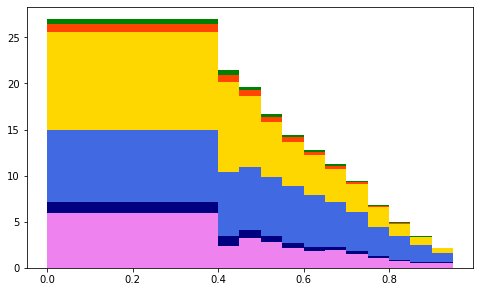

In [25]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0hp'
plotLabel = 'D0hp'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2.3 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# DL1Zg

[10.26768339 22.78504628 14.87578079  7.61080066  6.57373752]


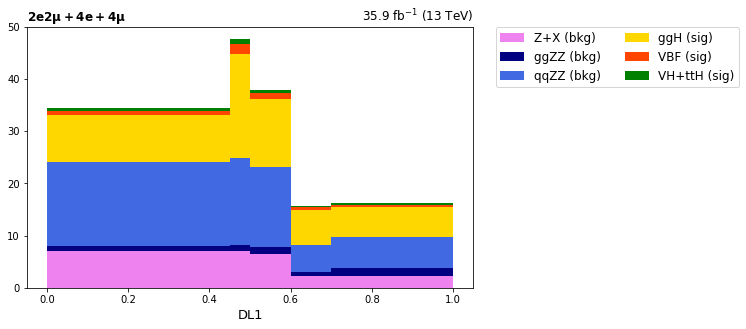

Bin1 1.6254218161923362
Bin2 3.2778482764967882
Bin3 2.3369663102834353
Bin4 2.1758431062544465
Bin5 1.7601882906463777
[ 4.95981768 12.18156302  6.48197488  2.29730957  2.09679999]


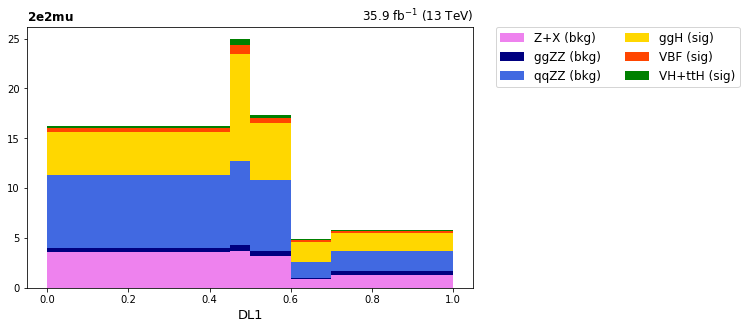

Bin1 1.2529945661398407
Bin2 2.66831834633986
Bin3 1.6433735012753412
Bin4 1.2341108321542844
Bin5 0.9697861421114882
[1.49189989 3.09807416 3.00892281 1.84453121 1.61452076]


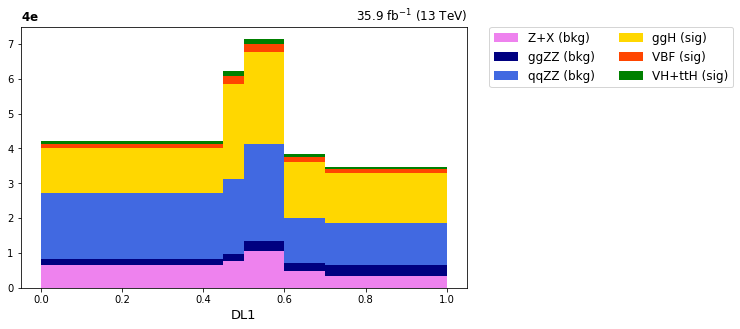

Bin1 0.815965553744014
Bin2 1.4898322361775675
Bin3 1.2875157855981383
Bin4 1.1325097815903946
Bin5 1.0333734750578443
[3.81596582 7.50540911 5.3848831  3.46895988 2.86241678]


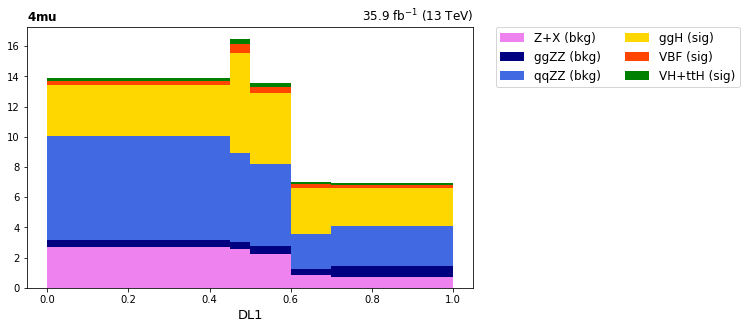

Bin1 1.0417695705842605
Bin2 2.0574454826673674
Bin3 1.5914287477491187
Bin4 1.5610790881695087
Bin5 1.2357267002486791
{('2016', 'inclusive', 0): 1.6254218161923362, ('2016', 'inclusive', 1): 3.2778482764967882, ('2016', 'inclusive', 2): 2.3369663102834353, ('2016', 'inclusive', 3): 2.1758431062544465, ('2016', 'inclusive', 4): 1.7601882906463777, ('2016', '2e2mu', 0): 1.2529945661398407, ('2016', '2e2mu', 1): 2.66831834633986, ('2016', '2e2mu', 2): 1.6433735012753412, ('2016', '2e2mu', 3): 1.2341108321542844, ('2016', '2e2mu', 4): 0.9697861421114882, ('2016', '4e', 0): 0.815965553744014, ('2016', '4e', 1): 1.4898322361775675, ('2016', '4e', 2): 1.2875157855981383, ('2016', '4e', 3): 1.1325097815903946, ('2016', '4e', 4): 1.0333734750578443, ('2016', '4mu', 0): 1.0417695705842605, ('2016', '4mu', 1): 2.0574454826673674, ('2016', '4mu', 2): 1.5914287477491187, ('2016', '4mu', 3): 1.5610790881695087, ('2016', '4mu', 4): 1.2357267002486791}


In [16]:
binBoundaries = [0,0.45,0.5,0.6,0.7,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'DL1Zg'
plotLabel = 'DL1Zg'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

13
[0, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.9500000000000002, 1.0000000000000002]


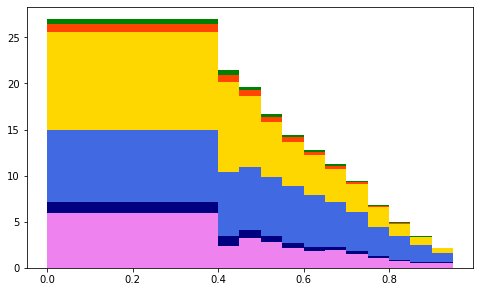

In [25]:
massInf=105
massSup=140
NNLOPS=False

variable = 'D0hp'
plotLabel = 'D0hp'
vbf = [d_sig[year]['VBF'] for year in [2016]] 
ggh = [d_sig[year]['ggH'] for year in [2016]]
other = [d_sig[year]['other'] for year in [2016]]
qqzz = [d_bkg[year]['qqzz'] for year in [2016]]
ggzz = [d_bkg[year]['ggzz'] for year in [2016]]
zx = [d_ZX[year] for year in [2016]]
dfVBF = pd.concat(vbf)
dfGGH = pd.concat(ggh)
dfOTH = pd.concat(other)
dfQQZZ = pd.concat(qqzz)
dfGGZZ = pd.concat(ggzz)
dfZX = pd.concat(zx)

step=0.05
edge=0.05
initial_boundary=0.0
Z_cut = 2.3 #Cut-off in Asimov significance
optimization_upper(massInf,massSup,variable,Z_cut,step, edge, initial_boundary)

In [ ]:
binBoundaries = [0,0.4,0.55,0.7,0.85,1] 
massInf=105
massSup=140
NNLOPS=False
variable = 'D0m'
plotLabel = 'D0m'

significance_setup(binBoundaries, massInf, massSup, variable, NNLOPS, plotLabel)

# -----------------------------------------------Pt_j1-----------------------------------------------

In [6]:
branches = ['ZZMass', 'nCleanedJetsPt30', 'JetPt', 'Z1Flav', 'Z2Flav', 'overallEventWeight', 'L1prefiringWeight'] 
dfVBF = ttreeVBF.pandas.df(branches, flatten = False)
# dfGGH = ttreeGGH.pandas.df(branches, flatten = False) 
# dfQQZZ = ttreeQQZZ.pandas.df(branches, flatten = False) 
# dfBBH = ttreeBBH.pandas.df(branches, flatten = False)
# dfTTH = ttreeTTH.pandas.df(branches, flatten = False)
# dfWmH = ttreeWmH.pandas.df(branches, flatten = False)
# dfWpH = ttreeWpH.pandas.df(branches, flatten = False)
# dfZH = ttreeZH.pandas.df(branches, flatten = False)
# dfGGZH = ttreeGGZH.pandas.df(branches, flatten = False)
# dfTQH = ttreeTQH.pandas.df(branches, flatten = False)

# # Merge all production modes (except VBF, ggH, qqZZ)
# frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
# dfOTH = pd.concat(frames)

# # To calculate Pt_J1 and Pt_J2 I need at least 2 JETs
# dfVBF = dfVBF[dfVBF.nCleanedJetsPt30>=2] 
# dfGGH = dfGGH[dfGGH.nCleanedJetsPt30>=2]
# dfQQZZ = dfQQZZ[dfQQZZ.nCleanedJetsPt30>=2]
# dfOTH = dfOTH[dfOTH.nCleanedJetsPt30>=2]

NameError: name 'ttreeVBF' is not defined

In [ ]:
dfVBF['Pt_J1'] = [max(i) for i in dfVBF.JetPt]
dfGGH['Pt_J1'] = [max(i) for i in dfGGH.JetPt]
dfQQZZ['Pt_J1'] = [max(i) for i in dfQQZZ.JetPt]
dfOTH['Pt_J1'] = [max(i) for i in dfOTH.JetPt]

In [ ]:
dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
binning = [30,55,120,350]

n, bins, _= plt.hist([dfQQZZ.Pt_J1, dfGGH.Pt_J1, dfVBF.Pt_J1, dfOTH.Pt_J1], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('P$_{T,J1}$ [GeV]', fontsize = 13)
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/Pt_J1(total).png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Suddivision in different final states)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 5 # Cut-off in Asimov significance
step = 5
edge = 300
binning = [edge, 1500]

while binning[0] > 30:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.Pt_J1, dfGGH.Pt_J1, dfVBF.Pt_J1, dfOTH.Pt_J1], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 30:
                break
    if binning[0] > 30:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [30, 65, 100, 150, 1500]
n, bins, _= plt.hist([dfQQZZ.Pt_J1, dfGGH.Pt_J1, dfVBF.Pt_J1, dfOTH.Pt_J1], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlim(30,300)
plt.xlabel('P$_{T,J1}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/Pt_J1_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i]))
    i += 1
    
asi

# Asimov with bkg=ggH+qqzz and sig=VBF

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 0.7 # Cut-off in Asimov significance
step = 5
edge = 300
binning = [edge, 1500]

while binning[0] > 30:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.Pt_J1, dfGGH.Pt_J1, dfOTH.Pt_J1, dfVBF.Pt_J1], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label = ['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
            bkg = n[2]
            sig = n[3] - n[2]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 30:
                break
    if binning[0] > 30:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [30, 75, 120, 1500]
n, bins, _= plt.hist([dfQQZZ.Pt_J1, dfGGH.Pt_J1, dfOTH.Pt_J1, dfVBF.Pt_J1], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
plt.xlim(30,300)
plt.xlabel('P$_{T,J1}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/Pt_J1_jet.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[2]
sig = n[3] - n[2]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------y-----------------------------------------------

In [7]:
# Chose the variables in the branches to analize
branches = ['ZZMass', 'Z1Flav', 'Z2Flav', 'ZZPt', 'Z1Mass', 'Z2Mass', 'ZZEta', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches)
# dfGGH = ttreeGGH.pandas.df(branches) 
# dfQQZZ = ttreeQQZZ.pandas.df(branches) 
# dfBBH = ttreeBBH.pandas.df(branches)
# dfTTH = ttreeTTH.pandas.df(branches)
# dfWmH = ttreeWmH.pandas.df(branches)
# dfWpH = ttreeWpH.pandas.df(branches)
# dfZH = ttreeZH.pandas.df(branches)
# dfGGZH = ttreeGGZH.pandas.df(branches)
# dfTQH = ttreeTQH.pandas.df(branches)

# # Merge all production modes (except VBF, ggH, qqZZ)
# frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
# dfOTH = pd.concat(frames)

# dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
# dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
# dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
# dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
# dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
# dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
# dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
# dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

# # Rapidity (absolute value)
# dfVBF['ZZy'] = rapidity(dfVBF['ZZPt'], dfVBF['ZZEta'])
# dfGGH['ZZy'] = rapidity(dfGGH['ZZPt'], dfGGH['ZZEta'])
# dfQQZZ['ZZy'] = rapidity(dfQQZZ['ZZPt'], dfQQZZ['ZZEta'])
# dfOTH['ZZy'] = rapidity(dfOTH['ZZPt'], dfOTH['ZZEta'])

NameError: name 'ttreeVBF' is not defined

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
binning = [0, 0.3, 0.9, 1.2, 2.5]

n, bins, _= plt.hist([dfQQZZ.ZZy, dfGGH.ZZy, dfVBF.ZZy, dfOTH.ZZy], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('|y(H)|', fontsize = 13)
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/ZZy.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1

asi

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 4.5 # Cut-off in Asimov significance
step = 0.1
edge = 2.4
binning = [edge, 2.5]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.ZZy, dfGGH.ZZy, dfVBF.ZZy, dfOTH.ZZy], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.4, 0.9, 2.5]
n, bins, _= plt.hist([dfQQZZ.ZZy, dfGGH.ZZy, dfVBF.ZZy, dfOTH.ZZy], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('|y(H)|', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/ZZy_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------m_JJ-----------------------------------------------

In [ ]:
# Chose the variables in the branches to analize
branches = ['nCleanedJetsPt30', 'ZZMass', 'Z1Flav', 'Z2Flav', 'DiJetMass', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches)
dfGGH = ttreeGGH.pandas.df(branches) 
dfQQZZ = ttreeQQZZ.pandas.df(branches) 
dfBBH = ttreeBBH.pandas.df(branches)
dfTTH = ttreeTTH.pandas.df(branches)
dfWmH = ttreeWmH.pandas.df(branches)
dfWpH = ttreeWpH.pandas.df(branches)
dfZH = ttreeZH.pandas.df(branches)
dfGGZH = ttreeGGZH.pandas.df(branches)
dfTQH = ttreeTQH.pandas.df(branches)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

dfVBF = dfVBF[dfVBF.nCleanedJetsPt30>=2]
dfGGH = dfGGH[dfGGH.nCleanedJetsPt30>=2]
dfQQZZ = dfQQZZ[dfQQZZ.nCleanedJetsPt30>=2]
dfOTH = dfOTH[dfOTH.nCleanedJetsPt30>=2]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 5 # Cut-off in Asimov significance
step = 5
edge = 800
binning = [edge, 7160]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.DiJetMass, dfGGH.DiJetMass, dfVBF.DiJetMass, dfOTH.DiJetMass], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 85, 170, 400, 800, 7160]
n, bins, _= plt.hist([dfQQZZ.DiJetMass, dfGGH.DiJetMass, dfVBF.DiJetMass, dfOTH.DiJetMass], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlim(0,1000)
plt.xlabel('m$_{jj}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('optimal', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/JetMass_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# Asimov with bkg=ggH+qqzz and sig=VBF

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 1 # Cut-off in Asimov significance
step = 5
edge = 1800
binning = [edge, 7160]

while binning[0] > 500:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.DiJetMass, dfGGH.DiJetMass, dfOTH.DiJetMass, dfVBF.DiJetMass], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
            bkg = n[2]
            sig = n[3] - n[2]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 500:
                break
    if binning[0] > 500:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [500, 745, 1185, 1795, 7160]
n, bins, _= plt.hist([dfQQZZ.DiJetMass, dfGGH.DiJetMass, dfOTH.DiJetMass, dfVBF.DiJetMass], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
plt.xlim(500,2000)
plt.xlabel('m$_{jj}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/DiJetMass_jet.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[2] 
sig = n[3] - n[2]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------$\Delta\eta_{jj}$-----------------------------------------------

In [ ]:
# Chose the variables in the branches to analize
branches = ['nCleanedJetsPt30', 'ZZMass', 'Z1Flav', 'Z2Flav', 'DiJetDEta', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches)
dfGGH = ttreeGGH.pandas.df(branches) 
dfQQZZ = ttreeQQZZ.pandas.df(branches) 
dfBBH = ttreeBBH.pandas.df(branches)
dfTTH = ttreeTTH.pandas.df(branches)
dfWmH = ttreeWmH.pandas.df(branches)
dfWpH = ttreeWpH.pandas.df(branches)
dfZH = ttreeZH.pandas.df(branches)
dfGGZH = ttreeGGZH.pandas.df(branches)
dfTQH = ttreeTQH.pandas.df(branches)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

dfVBF = dfVBF[dfVBF.nCleanedJetsPt30>=2]
dfGGH = dfGGH[dfGGH.nCleanedJetsPt30>=2]
dfQQZZ = dfQQZZ[dfQQZZ.nCleanedJetsPt30>=2]
dfOTH = dfOTH[dfOTH.nCleanedJetsPt30>=2]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 3.5 # Cut-off in Asimov significance
step = 0.5
edge = 8.5
binning = [edge, 10]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.DiJetDEta), abs(dfGGH.DiJetDEta), abs(dfVBF.DiJetDEta), abs(dfOTH.DiJetDEta)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[2] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 1, 2.5, 4.5, 10]
n, bins, _= plt.hist([abs(dfQQZZ.DiJetDEta), abs(dfGGH.DiJetDEta), abs(dfVBF.DiJetDEta), abs(dfOTH.DiJetDEta)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('$\Delta\eta_{jj}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/DiJetDEta_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# Asimov with bkg=ggH+qqzz and sig=VBF

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 0.7 # Cut-off in Asimov significance
step = 0.1
edge = 1800
binning = [8.5, 10]

while binning[0] > 4:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.DiJetDEta, dfGGH.DiJetDEta, dfOTH.DiJetDEta, dfVBF.DiJetDEta], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
            bkg = n[2]
            sig = n[3] - n[2]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 4:
                break
    if binning[0] > 4:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [4, 5, 6, 10]
n, bins, _= plt.hist([dfQQZZ.DiJetDEta, dfGGH.DiJetDEta, dfOTH.DiJetDEta, dfVBF.DiJetDEta], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
plt.xlabel('$\Delta\eta_{jj}$', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/DiJetDEta_jet.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[2]
sig = n[3] - n[2]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------$\Delta\phi_{jj}$-----------------------------------------------

In [ ]:
def diff(my_list):
    if len(my_list) <= 1:
        return -999
    else:
        return(my_list[0] - my_list[1])

In [ ]:
def diff_phi(phi):
    DPhi = diff(phi)
    if DPhi > 3.14:
        DPhi = DPhi - 3.14
    if DPhi < - 3.14:
        DPhi = DPhi + 3.14
    return DPhi

In [ ]:
branches = ['ZZMass', 'nCleanedJetsPt30', 'JetPhi', 'overallEventWeight', 'L1prefiringWeight'] # Delta information about JETs
dfVBF = ttreeVBF.pandas.df(branches, flatten = False)
dfGGH = ttreeGGH.pandas.df(branches, flatten = False) 
dfQQZZ = ttreeQQZZ.pandas.df(branches, flatten = False) 
dfBBH = ttreeBBH.pandas.df(branches, flatten = False)
dfTTH = ttreeTTH.pandas.df(branches, flatten = False)
dfWmH = ttreeWmH.pandas.df(branches, flatten = False)
dfWpH = ttreeWpH.pandas.df(branches, flatten = False)
dfZH = ttreeZH.pandas.df(branches, flatten = False)
dfGGZH = ttreeGGZH.pandas.df(branches, flatten = False)
dfTQH = ttreeTQH.pandas.df(branches, flatten = False)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

# To calculate DiJetDiPhi I need at least 2 JETs
dfVBF = dfVBF[dfVBF.nCleanedJetsPt30>=2] 
dfGGH = dfGGH[dfGGH.nCleanedJetsPt30>=2]
dfQQZZ = dfQQZZ[dfQQZZ.nCleanedJetsPt30>=2]
dfOTH = dfOTH[dfOTH.nCleanedJetsPt30>=2]

# DeltaPhi
dfVBF['DeltaPhi'] = [abs(diff_phi(phi)) for phi in dfVBF.JetPhi]
dfGGH['DeltaPhi'] = [abs(diff_phi(phi)) for phi in dfGGH.JetPhi]
dfQQZZ['DeltaPhi'] = [abs(diff_phi(phi)) for phi in dfQQZZ.JetPhi]
dfOTH['DeltaPhi'] = [abs(diff_phi(phi)) for phi in dfOTH.JetPhi]

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 4.5 # Cut-off in Asimov significance
step = 0.1
edge = 3.13
binning = [edge, 3.14]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.DeltaPhi), abs(dfGGH.DeltaPhi), abs(dfVBF.DeltaPhi), abs(dfOTH.DeltaPhi)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.5, 1.2, 2, 3.14]
n, bins, _= plt.hist([abs(dfQQZZ.DeltaPhi), abs(dfGGH.DeltaPhi), abs(dfVBF.DeltaPhi), abs(dfOTH.DeltaPhi)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.xlabel('$\Delta\phi_{jj}$', fontsize = 13)
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/DiJetDiPhi_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# Asimov with bkg=ggH+qqzz and sig=VBF

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 0.6 # Cut-off in Asimov significance
step = 0.1
binning = [3.13, 3.14]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.DeltaPhi), abs(dfGGH.DeltaPhi), abs(dfOTH.DeltaPhi), abs(dfVBF.DeltaPhi)], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (sig)', 'Others (sig)', 'VBF (sig)'], stacked = True)
            bkg = n[2]
            sig = n[3] - n[2]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.4, 1, 2, 3.14]
n, bins, _= plt.hist([abs(dfQQZZ.DeltaPhi), abs(dfGGH.DeltaPhi), abs(dfOTH.DeltaPhi), abs(dfVBF.DeltaPhi)], bins = binning, weights = [Wqqzz, Wggh, Woth, Wvbf], color = ['royalblue', 'gold', 'green', 'orangered'], histtype='bar', label =['qqzz (bkg)', 'ggH (bkg)', 'Others (bkg)', 'VBF (sig)'], stacked = True)
plt.xlabel('$\Delta\phi_{jj}$', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/DeltaPhi_jet.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[2]
sig = n[3] - n[2]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------Pt_l1----------------------------------------------

In [ ]:
branches = ['ZZMass', 'LepPt', 'LepLepId', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches, flatten = False)
dfGGH = ttreeGGH.pandas.df(branches, flatten = False) 
dfQQZZ = ttreeQQZZ.pandas.df(branches, flatten = False) 
dfBBH = ttreeBBH.pandas.df(branches, flatten = False)
dfTTH = ttreeTTH.pandas.df(branches, flatten = False)
dfWmH = ttreeWmH.pandas.df(branches, flatten = False)
dfWpH = ttreeWpH.pandas.df(branches, flatten = False)
dfZH = ttreeZH.pandas.df(branches, flatten = False)
dfGGZH = ttreeGGZH.pandas.df(branches, flatten = False)
dfTQH = ttreeTQH.pandas.df(branches, flatten = False)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

dfVBF['Pt_l1'] = [max(i) for i in dfVBF.LepPt]
dfGGH['Pt_l1'] = [max(i) for i in dfGGH.LepPt]
dfQQZZ['Pt_l1'] = [max(i) for i in dfQQZZ.LepPt]
dfOTH['Pt_l1'] = [max(i) for i in dfOTH.LepPt]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 4.5 # Cut-off in Asimov significance
step = 5
edge = 390
binning = [edge, 700]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.Pt_l1, dfGGH.Pt_l1, dfVBF.Pt_l1, dfOTH.Pt_l1 ], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 35, 45, 55, 75, 110, 700]
n, bins, _= plt.hist([dfQQZZ.Pt_l1, dfGGH.Pt_l1, dfVBF.Pt_l1, dfOTH.Pt_l1 ], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlim([0, 150])
plt.xlabel('P$_{T,l1}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/Ptl1_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------m$_{Z2}$----------------------------------------------

In [ ]:
branches = ['ZZMass', 'Z2Mass', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches)
dfGGH = ttreeGGH.pandas.df(branches) 
dfQQZZ = ttreeQQZZ.pandas.df(branches) 
dfBBH = ttreeBBH.pandas.df(branches)
dfTTH = ttreeTTH.pandas.df(branches)
dfWmH = ttreeWmH.pandas.df(branches)
dfWpH = ttreeWpH.pandas.df(branches)
dfZH = ttreeZH.pandas.df(branches)
dfGGZH = ttreeGGZH.pandas.df(branches)
dfTQH = ttreeTQH.pandas.df(branches)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov
sig = bkg = asi = 0
Z = 3.5 # Cut-off in Asimov significance
step = 5
edge = 60
binning = [edge, 70]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([dfQQZZ.Z2Mass, dfGGH.Z2Mass, dfVBF.Z2Mass, dfOTH.Z2Mass], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 25, 35, 45, 70]
n, bins, _= plt.hist([dfQQZZ.Z2Mass, dfGGH.Z2Mass, dfVBF.Z2Mass, dfOTH.Z2Mass], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('m$_{Z2}$ [GeV]', fontsize = 13)
plt.title('$\\bf{2e2\mu + 4e + 4\mu}$', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/Z2Mass_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# -----------------------------------------------Angles----------------------------------------------

# $\phi$

In [ ]:
branches = ['ZZMass', 'helphi', 'helcosthetaZ1', 'helcosthetaZ2', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches)
dfGGH = ttreeGGH.pandas.df(branches) 
dfQQZZ = ttreeQQZZ.pandas.df(branches) 
dfBBH = ttreeBBH.pandas.df(branches)
dfTTH = ttreeTTH.pandas.df(branches)
dfWmH = ttreeWmH.pandas.df(branches)
dfWpH = ttreeWpH.pandas.df(branches)
dfZH = ttreeZH.pandas.df(branches)
dfGGZH = ttreeGGZH.pandas.df(branches)
dfTQH = ttreeTQH.pandas.df(branches)

# Merge all production modes (except VBF, ggH, qqZZ)
frames = [dfBBH, dfTTH, dfWmH, dfWpH, dfZH, dfGGZH, dfTQH]
dfOTH = pd.concat(frames)

dfVBF = dfVBF[dfVBF.ZZMass>=lim_inf]
dfVBF = dfVBF[dfVBF.ZZMass<=lim_sup]
dfGGH = dfGGH[dfGGH.ZZMass>=lim_inf]
dfGGH = dfGGH[dfGGH.ZZMass<=lim_sup]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=lim_inf]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=lim_sup]
dfOTH = dfOTH[dfOTH.ZZMass>=lim_inf]
dfOTH = dfOTH[dfOTH.ZZMass<=lim_sup]

In [ ]:
Wvbf = lumi * 1000 * xsecVBF * dfVBF.overallEventWeight * dfVBF.L1prefiringWeight / nMC_VBF
Wggh = lumi * 1000 * xsecGGH * dfGGH.overallEventWeight * dfGGH.L1prefiringWeight / nMC_GGH
Wqqzz = lumi * 1000 * xsecQQZZ * dfQQZZ.overallEventWeight * dfQQZZ.L1prefiringWeight / nMC_QQZZ
Woth = lumi * 1000 * xsecOTH * dfOTH.overallEventWeight * dfOTH.L1prefiringWeight / nMC_OTH

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 5 # Cut-off in Asimov significance
step = 0.1
edge = 3.13
binning = [edge, 3.15]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.helphi), abs(dfGGH.helphi), abs(dfVBF.helphi), abs(dfOTH.helphi)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.3, 1, 1.8, 2.5, 3.15]
n, bins, _= plt.hist([abs(dfQQZZ.helphi), abs(dfGGH.helphi), abs(dfVBF.helphi), abs(dfOTH.helphi)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlim([0,3.14])
plt.xlabel('$\phi$', fontsize = 13)
plt.title('optimal', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/helphi_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# $\theta_1$

In [ ]:
# optimization Asimov

sig = bkg = asi = 0
Z = 4 # Cut-off in Asimov significance
step = 0.1
edge = 0.9
binning = [edge, 1]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.helcosthetaZ1), abs(dfGGH.helcosthetaZ1), abs(dfVBF.helcosthetaZ1), abs(dfOTH.helcosthetaZ1)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.2, 0.4, 0.7, 1]
n, bins, _= plt.hist([abs(dfQQZZ.helcosthetaZ1), abs(dfGGH.helcosthetaZ1), abs(dfVBF.helcosthetaZ1), abs(dfOTH.helcosthetaZ1)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('$\cos\\theta_1$', fontsize = 13)
plt.title('optimal', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/costheta1_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# $\theta_2$

In [ ]:
# optimization Asimov
sig = bkg = asi = 0
Z = 4 # Cut-off in Asimov significance
step = 0.1
edge = 0.9
binning = [edge, 1]

while binning[0] > 0:
    asi = 0
    while asi < Z:
            n, bins, _= plt.hist([abs(dfQQZZ.helcosthetaZ2), abs(dfGGH.helcosthetaZ2), abs(dfVBF.helcosthetaZ2), abs(dfOTH.helcosthetaZ2)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
            bkg = n[0]
            sig = n[3] - n[0]
            asi = ams(sig[0], bkg[0], 0.1*bkg[0])
            binning[0] -= step
            if binning[0] <= 0:
                break
    if binning[0] > 0:
        binning.insert(0, binning[0] - step)
    
binning

In [ ]:
binning = [0, 0.2, 0.4, 0.7, 1]
print(binning)
n, bins, _= plt.hist([abs(dfQQZZ.helcosthetaZ2), abs(dfGGH.helcosthetaZ2), abs(dfVBF.helcosthetaZ2), abs(dfOTH.helcosthetaZ2)], bins = binning, weights = [Wqqzz, Wggh, Wvbf, Woth], color = colors, histtype='bar', label = labels, stacked = True)
plt.xlabel('$\cos\\theta_2$', fontsize = 13)
plt.title('optimal', loc = 'left')
plt.title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
plt.legend()
plt.savefig('plot/plot_asimov/costheta2_opt.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
# Signal and background events to calculate Asimov (Total)

bkg = n[0]
sig = n[3] - n[0]
i = 0
asi = []
while i<len(binning)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
    
asi

# ----------------------------------------------Combo----------------------------------------------

# PT_J1-PT_J2

In [ ]:
branches = ['nCleanedJetsPt30', 'ZZMass', 'JetPt', 'JetPhi', 'LepPt', 'ZZPt', 'overallEventWeight', 'L1prefiringWeight']
dfVBF = ttreeVBF.pandas.df(branches, flatten = False)
dfGGH = ttreeGGH.pandas.df(branches, flatten = False) 
dfQQZZ = ttreeQQZZ.pandas.df(branches, flatten = False)

dfVBF = dfVBF[dfVBF.ZZMass>=105]
dfVBF = dfVBF[dfVBF.ZZMass<=140]
dfGGH = dfGGH[dfGGH.ZZMass>=105]
dfGGH = dfGGH[dfGGH.ZZMass<=140]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass>=105]
dfQQZZ = dfQQZZ[dfQQZZ.ZZMass<=140]

dfVBF = dfVBF[dfVBF.nCleanedJetsPt30>=2] 
dfGGH = dfGGH[dfGGH.nCleanedJetsPt30>=2]
dfQQZZ = dfQQZZ[dfQQZZ.nCleanedJetsPt30>=2]

dfVBF['Pt_J1'] = [max(i) for i in dfVBF.JetPt]
dfVBF['Pt_J2'] = [i[1] for i in dfVBF.JetPt]
dfVBF['DPhi'] = [diff(phi) for phi in dfVBF.JetPhi]
dfVBF['Pt_l1'] = [max(i) for i in dfVBF.LepPt]

dfGGH['Pt_J1'] = [max(i) for i in dfGGH.JetPt]
dfGGH['Pt_J2'] = [i[1] for i in dfGGH.JetPt]
dfGGH['DPhi'] = [diff(phi) for phi in dfGGH.JetPhi]
dfGGH['Pt_l1'] = [max(i) for i in dfGGH.LepPt]

dfQQZZ['Pt_J1'] = [max(i) for i in dfQQZZ.JetPt]
dfQQZZ['Pt_J2'] = [i[1] for i in dfQQZZ.JetPt]
dfQQZZ['DPhi'] = [diff(phi) for phi in dfQQZZ.JetPhi]
dfQQZZ['Pt_l1'] = [max(i) for i in dfQQZZ.LepPt]

In [ ]:
dfVBF1 = dfVBF[(dfVBF.Pt_J1>=30)&(dfVBF.Pt_J1<=120)]
dfVBF2 = dfVBF[(dfVBF.Pt_J1>120)&(dfVBF.Pt_J1<=350)]
#dfVBF3 = dfVBF[(dfVBF.Pt_J1>120)&(dfVBF.Pt_J1<=350)]

dfGGH1 = dfGGH[(dfGGH.Pt_J1>=30)&(dfGGH.Pt_J1<=120)]
dfGGH2 = dfGGH[(dfGGH.Pt_J1>120)&(dfGGH.Pt_J1<=350)]
#dfGGH3 = dfGGH[(dfGGH.Pt_J1>120)&(dfGGH.Pt_J1<=350)]

dfQQZZ1 = dfQQZZ[(dfQQZZ.Pt_J1>=30)&(dfQQZZ.Pt_J1<=120)]
dfQQZZ2 = dfQQZZ[(dfQQZZ.Pt_J1>120)&(dfQQZZ.Pt_J1<=350)]
#dfQQZZ3 = dfQQZZ[(dfQQZZ.Pt_J1>120)&(dfQQZZ.Pt_J1<=350)]

In [ ]:
Wvbf1 = lumi * 1000 * xsecVBF * dfVBF1.overallEventWeight * dfVBF1.L1prefiringWeight / nMC_VBF
Wggh1 = lumi * 1000 * xsecGGH * dfGGH1.overallEventWeight * dfGGH1.L1prefiringWeight / nMC_GGH
Wqqzz1 = lumi * 1000 * xsecQQZZ * dfQQZZ1.overallEventWeight * dfQQZZ1.L1prefiringWeight / nMC_QQZZ

Wvbf2 = lumi * 1000 * xsecVBF * dfVBF2.overallEventWeight * dfVBF2.L1prefiringWeight / nMC_VBF
Wggh2 = lumi * 1000 * xsecGGH * dfGGH2.overallEventWeight * dfGGH2.L1prefiringWeight / nMC_GGH
Wqqzz2 = lumi * 1000 * xsecQQZZ * dfQQZZ2.overallEventWeight * dfQQZZ2.L1prefiringWeight / nMC_QQZZ

# Wvbf3 = lumi * 1000 * xsecVBF * dfVBF3.overallEventWeight * dfVBF3.L1prefiringWeight / nMC_VBF
# Wggh3 = lumi * 1000 * xsecGGH * dfGGH3.overallEventWeight * dfGGH3.L1prefiringWeight / nMC_GGH
# Wqqzz3 = lumi * 1000 * xsecQQZZ * dfQQZZ3.overallEventWeight * dfQQZZ3.L1prefiringWeight / nMC_QQZZ

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3)
ax0, ax1, ax2 = axes.flatten()


n0, bins0, _ = ax0.hist([dfQQZZ1.Pt_J2, dfGGH1.Pt_J2, dfVBF1.Pt_J2], bins = [30, 40, 55], weights = [Wqqzz1, Wggh1, Wvbf1], color = colors, histtype='bar', label =['qqzz', 'ggH', 'VBF'], stacked = True)
ax0.legend()
ax0.set_title('P$_{T,J1}\in[30, 55]$', loc = 'left')
ax0.set_title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
ax0.set_xlabel('P$_{T,J2}$', fontweight = 'bold')
ax0.xaxis.set_label_coords(1.05, -0.025)

n1, bins1, _ = ax1.hist([dfQQZZ2.Pt_J2, dfGGH2.Pt_J2, dfVBF2.Pt_J2], bins = [30, 45, 80, 125], weights = [Wqqzz2, Wggh2, Wvbf2], color = colors, histtype='bar', label =['qqzz', 'ggH', 'VBF'], stacked = True)
ax1.legend()
ax1.set_title('P$_{T,J1}\in(55, 120]$', loc = 'left')
ax1.set_title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
ax1.set_xlabel('P$_{T,J2}$', fontweight = 'bold')
ax1.xaxis.set_label_coords(1.05, -0.025)

# n2, bins2, _ = ax2.hist([dfQQZZ3.Pt_J2, dfGGH3.Pt_J2, dfVBF3.Pt_J2], bins = np.linspace(30, 350, 15), weights = [Wqqzz3, Wggh3, Wvbf3], color = colors, histtype='bar', label =['qqzz', 'ggH', 'VBF'], stacked = True)
# ax2.legend()
# ax2.set_title('P$_{T,J1}\in(120, 350]$', loc = 'left')
# ax2.set_title('137 fb$^{-1}$ (13 TeV)', loc = 'right')
# ax2.set_xlabel('P$_{T,J2}$', fontweight = 'bold')
# ax2.xaxis.set_label_coords(1.05, -0.025)

plt.subplots_adjust(top = 1, bottom = 0, left = 0, right = 3, hspace = 0.4)
plt.savefig('plot/plot_ZZ4l_sb/PtJ1-PtJ2-total.png', dpi=400, bbox_inches='tight') 
plt.show()

In [ ]:
bkg = n0[0]
sig = n0[2] - n0[0]
i = 0
asi = []
while i<len(bins0)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
print(asi)

bkg = n1[0]
sig = n1[2] - n1[0]
i = 0
asi = []
while i<len(bins1)-1:
    asi.append(ams(sig[i], bkg[i], 0.1*bkg[i]))
    i += 1
print(asi)